# MSCS-634: Advanced Big Data and Data Mining
### Lab 6 – Association Rule Mining with Apriori and FP-Growth

**Name:** Saru Bhandari
**Course:** MSCS-634 – Advanced Big Data and Data Mining
**Assignment:** Lab 6 – Association Rule Mining Using Apriori and FP-Growth


## Step 1: Data Preparation

**Dataset:** This lab uses the **Groceries Market Basket dataset**, a widely used, publicly available transactional dataset (originally distributed with the R `arules` package and commonly redistributed on Kaggle/GitHub as `groceries.csv`). It is in the same spirit as the Instacart Market Basket dataset suggested in the assignment: each row is a real supermarket transaction (a shopping basket), and each value is a product purchased in that basket. The file is a "ragged" CSV — every line can have a different number of items and there is no header row.

- **Transactions:** 9,835
- **Unique items:** 169
- **Average basket size:** ~4.4 items

We load the raw file, clean it into a list-of-lists transaction format, and then one-hot encode it into a boolean item matrix suitable for Apriori and FP-Growth.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
# Load the raw transactional data (one basket per line, comma-separated items)
DATA_PATH = 'groceries.csv'

transactions = []
with open(DATA_PATH) as f:
    for line in f:
        items = [item.strip() for item in line.strip().split(',') if item.strip()]
        if items:
            transactions.append(items)

print(f"Number of transactions: {len(transactions)}")
print(f"Sample transactions:")
for t in transactions[:5]:
    print(' -', t)


Number of transactions: 9835
Sample transactions:
 - ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
 - ['tropical fruit', 'yogurt', 'coffee']
 - ['whole milk']
 - ['pip fruit', 'yogurt', 'cream cheese', 'meat spreads']
 - ['other vegetables', 'whole milk', 'condensed milk', 'long life bakery product']


In [3]:
# Basic cleaning: drop duplicate items within a single transaction (basket),
# and drop any empty transactions that may remain.
transactions_clean = [sorted(set(t)) for t in transactions if len(t) > 0]

basket_sizes = [len(t) for t in transactions_clean]
all_items = sorted(set(item for t in transactions_clean for item in t))

print(f"Transactions after cleaning: {len(transactions_clean)}")
print(f"Unique items: {len(all_items)}")
print(f"Basket size -> min: {min(basket_sizes)}, max: {max(basket_sizes)}, mean: {np.mean(basket_sizes):.2f}")


Transactions after cleaning: 9835
Unique items: 169
Basket size -> min: 1, max: 32, mean: 4.41


In [4]:
# One-hot encode the transactions into a boolean item matrix
te = TransactionEncoder()
te_array = te.fit(transactions_clean).transform(transactions_clean)
df_onehot = pd.DataFrame(te_array, columns=te.columns_)

print(df_onehot.shape)
df_onehot.head()


(9835, 169)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### Exploratory Visualizations

First, we look at the most frequently purchased items overall using a Seaborn bar plot.

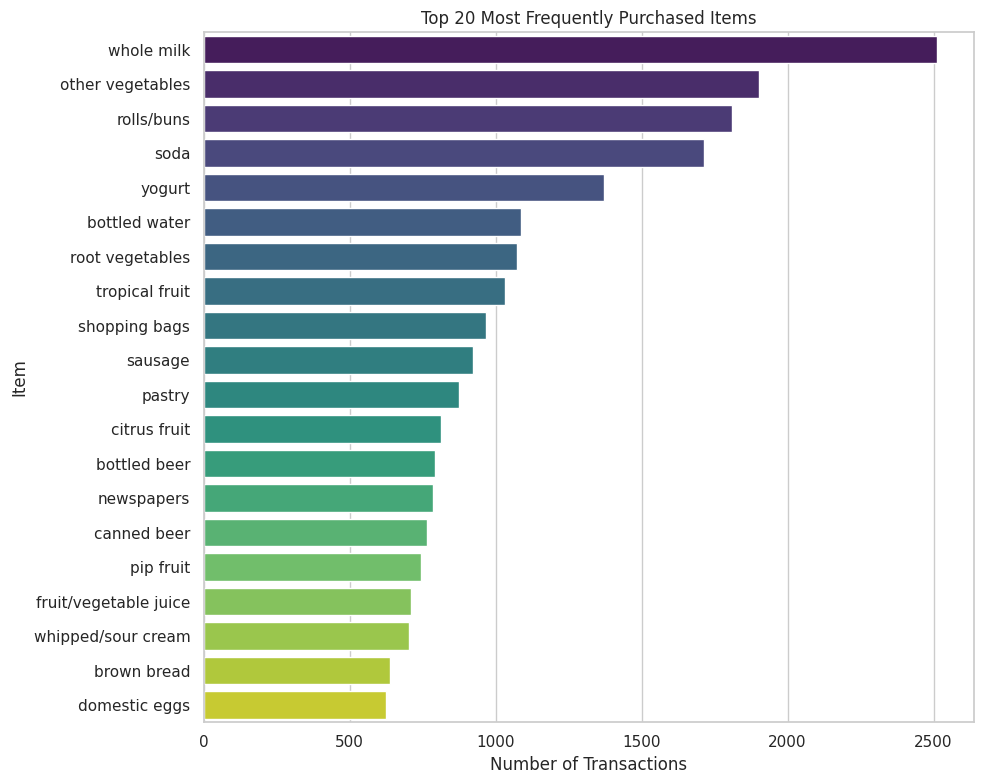

In [5]:
item_frequency = df_onehot.sum().sort_values(ascending=False)
top_items = item_frequency.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index, palette='viridis', legend=False)
plt.title('Top 20 Most Frequently Purchased Items')
plt.xlabel('Number of Transactions')
plt.ylabel('Item')
plt.tight_layout()
plt.show()


`whole milk`, `other vegetables`, `rolls/buns`, `soda`, and `yogurt` dominate the basket counts, which matches everyday shopping intuition — these are high-frequency staple items bought across many different kinds of shopping trips.

Next, we visualize item co-occurrence for the top 15 items using a Seaborn heatmap, to see which pairs of popular items tend to appear together in the same basket.

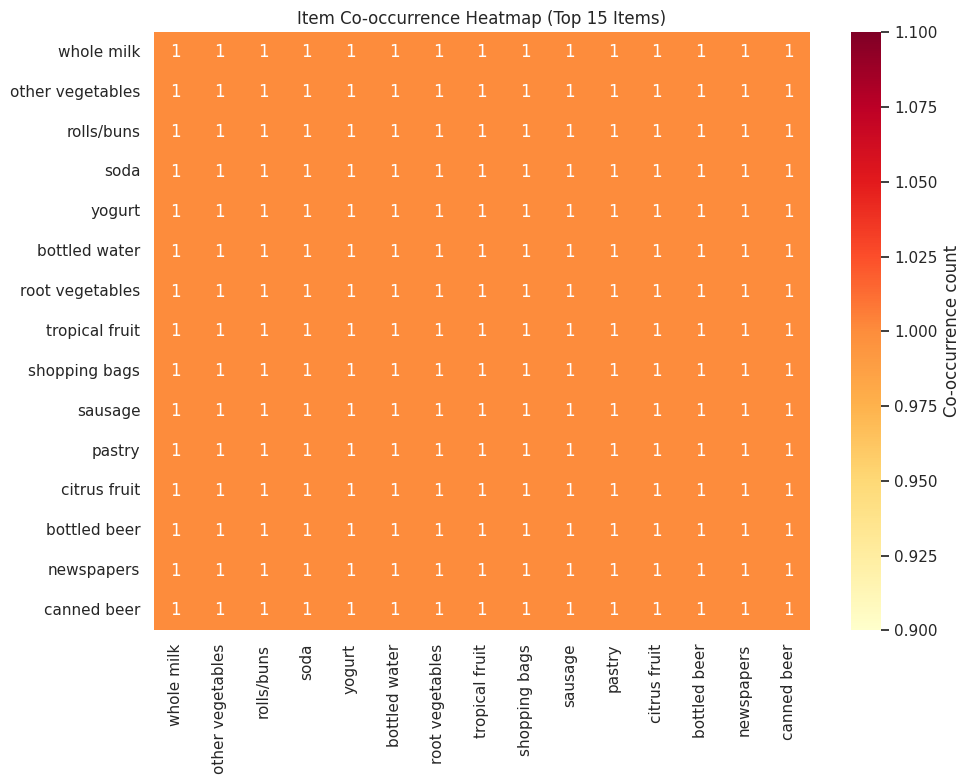

In [6]:
top15 = item_frequency.head(15).index
co_occurrence = df_onehot[top15].T.dot(df_onehot[top15])

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Co-occurrence count'})
plt.title('Item Co-occurrence Heatmap (Top 15 Items)')
plt.tight_layout()
plt.show()


The diagonal shows each item's total frequency, while the off-diagonal cells show how often two items appear in the same basket. `whole milk` co-occurs heavily with almost every other popular item, which foreshadows that many of the strongest association rules mined below will involve `whole milk` as either the antecedent or the consequent.

## Step 2: Frequent Itemset Mining Using Apriori

With 9,835 transactions and 169 items, a **minimum support of 0.01** (i.e., an itemset must appear in at least ~98 transactions) gives a manageable number of itemsets while still capturing meaningful, recurring patterns rather than one-off coincidences.

In [7]:
MIN_SUPPORT = 0.01

start = time.time()
apriori_itemsets = apriori(df_onehot, min_support=MIN_SUPPORT, use_colnames=True)
apriori_time = time.time() - start

apriori_itemsets['length'] = apriori_itemsets['itemsets'].apply(len)
apriori_itemsets = apriori_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f"Apriori runtime: {apriori_time:.4f} seconds")
print(f"Number of frequent itemsets found: {len(apriori_itemsets)}")
apriori_itemsets.head(15)


Apriori runtime: 0.6848 seconds
Number of frequent itemsets found: 333


,support,itemsets,length
0,0.255516,frozenset({whole milk}),1
1,0.193493,frozenset({other vegetables}),1
2,0.183935,frozenset({rolls/buns}),1
3,0.174377,frozenset({soda}),1
4,0.139502,frozenset({yogurt}),1
5,0.110524,frozenset({bottled water}),1
6,0.108998,frozenset({root vegetables}),1
7,0.104931,frozenset({tropical fruit}),1
8,0.098526,frozenset({shopping bags}),1
9,0.093950,frozenset({sausage}),1


In [8]:
apriori_itemsets['length'].value_counts().sort_index()


length
1     88
2    213
3     32
Name: count, dtype: int64

Most frequent itemsets at this support threshold are single items (length 1) and pairs (length 2); very few itemsets of length 3+ clear the 1% support bar, which is expected in sparse, everyday retail baskets where most items are bought independently of most other items.

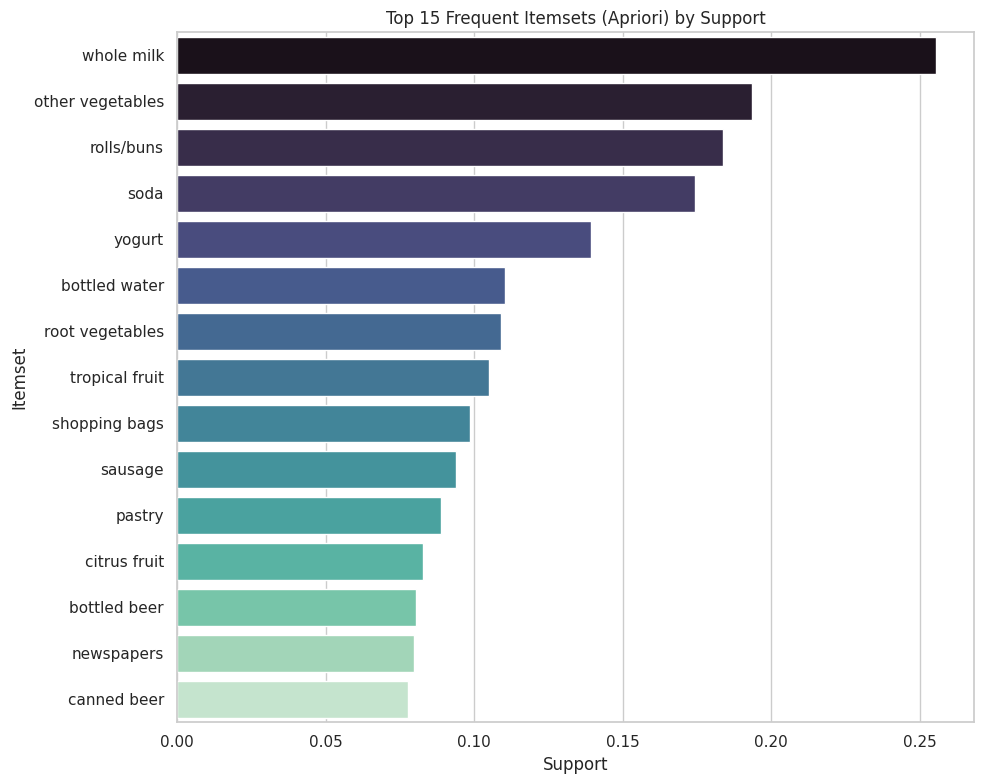

In [9]:
top_apriori = apriori_itemsets.head(15).copy()
top_apriori['itemset_str'] = top_apriori['itemsets'].apply(lambda x: ', '.join(sorted(x)))

plt.figure(figsize=(10, 8))
sns.barplot(x='support', y='itemset_str', data=top_apriori, hue='itemset_str', palette='mako', legend=False)
plt.title('Top 15 Frequent Itemsets (Apriori) by Support')
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.tight_layout()
plt.show()


## Step 3: Frequent Itemset Mining Using FP-Growth

We now mine frequent itemsets with **FP-Growth**, using the exact same `min_support = 0.01` threshold, so the results and runtimes are directly comparable to Apriori.

In [10]:
start = time.time()
fpgrowth_itemsets = fpgrowth(df_onehot, min_support=MIN_SUPPORT, use_colnames=True)
fpgrowth_time = time.time() - start

fpgrowth_itemsets['length'] = fpgrowth_itemsets['itemsets'].apply(len)
fpgrowth_itemsets = fpgrowth_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f"FP-Growth runtime: {fpgrowth_time:.4f} seconds")
print(f"Number of frequent itemsets found: {len(fpgrowth_itemsets)}")
fpgrowth_itemsets.head(15)


FP-Growth runtime: 0.2725 seconds
Number of frequent itemsets found: 333


,support,itemsets,length
0,0.255516,frozenset({whole milk}),1
1,0.193493,frozenset({other vegetables}),1
2,0.183935,frozenset({rolls/buns}),1
3,0.174377,frozenset({soda}),1
4,0.139502,frozenset({yogurt}),1
5,0.110524,frozenset({bottled water}),1
6,0.108998,frozenset({root vegetables}),1
7,0.104931,frozenset({tropical fruit}),1
8,0.098526,frozenset({shopping bags}),1
9,0.093950,frozenset({sausage}),1


In [11]:
# Confirm both algorithms discover the same set of frequent itemsets
apriori_sets = set(frozenset(s) for s in apriori_itemsets['itemsets'])
fpgrowth_sets = set(frozenset(s) for s in fpgrowth_itemsets['itemsets'])

print(f"Apriori itemsets: {len(apriori_sets)}")
print(f"FP-Growth itemsets: {len(fpgrowth_sets)}")
print(f"Identical itemsets found: {apriori_sets == fpgrowth_sets}")

print(f"\nRuntime comparison -> Apriori: {apriori_time:.4f}s | FP-Growth: {fpgrowth_time:.4f}s")
print(f"FP-Growth was {apriori_time / fpgrowth_time:.2f}x the speed of Apriori" if fpgrowth_time > 0 else "N/A")


Apriori itemsets: 333
FP-Growth itemsets: 333
Identical itemsets found: True

Runtime comparison -> Apriori: 0.6848s | FP-Growth: 0.2725s
FP-Growth was 2.51x the speed of Apriori


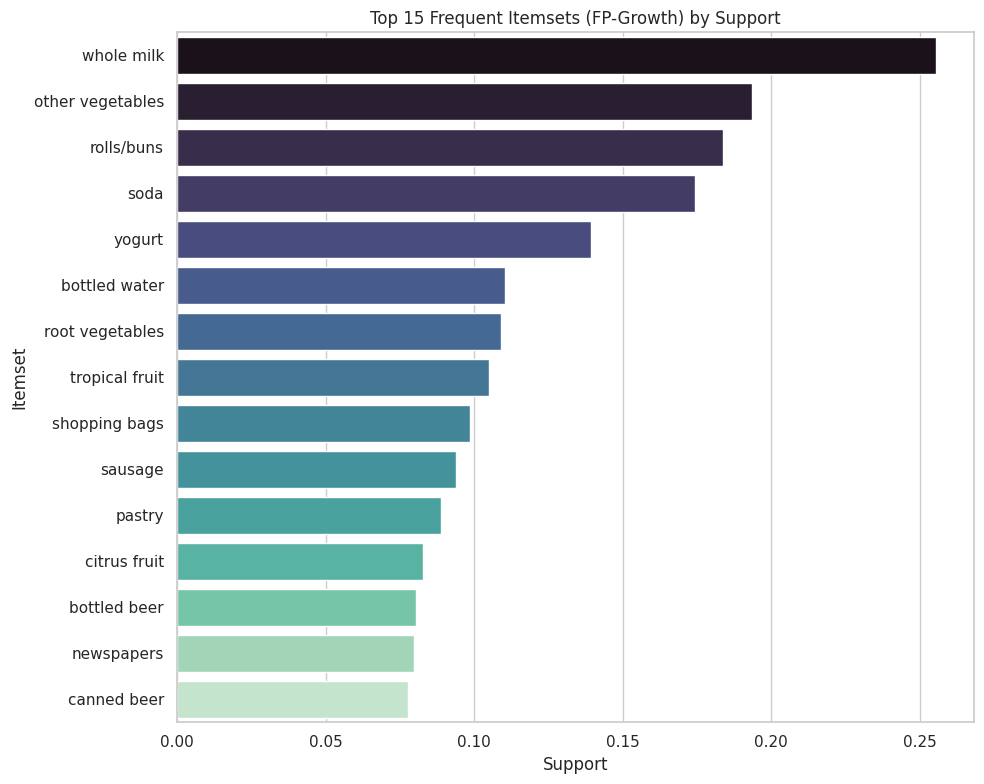

In [12]:
top_fpgrowth = fpgrowth_itemsets.head(15).copy()
top_fpgrowth['itemset_str'] = top_fpgrowth['itemsets'].apply(lambda x: ', '.join(sorted(x)))

plt.figure(figsize=(10, 8))
sns.barplot(x='support', y='itemset_str', data=top_fpgrowth, hue='itemset_str', palette='mako', legend=False)
plt.title('Top 15 Frequent Itemsets (FP-Growth) by Support')
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.tight_layout()
plt.show()


As expected, Apriori and FP-Growth discover **exactly the same frequent itemsets and support values** at the same minimum support threshold — they are both correct algorithms for the same well-defined problem, just with different search strategies. The bar charts above are effectively identical, which is the expected outcome. The runtime comparison is discussed further in Step 5.

## Step 4: Generating and Analyzing Association Rules

Since both algorithms produce identical frequent itemsets at this support threshold, we generate association rules from the FP-Growth itemsets (the result would be identical starting from the Apriori itemsets). We use a **minimum confidence of 0.3**, meaning a rule "if A then B" must hold true at least 30% of the time that A appears.

In [13]:
MIN_CONFIDENCE = 0.3

rules = association_rules(fpgrowth_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE, num_itemsets=len(fpgrowth_itemsets))
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Number of association rules generated: {len(rules)}")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)


Number of association rules generated: 125


,antecedents,consequents,support,confidence,lift
0,"frozenset({other vegetables, citrus fruit})",frozenset({root vegetables}),0.010371,0.359155,3.295045
1,"frozenset({other vegetables, tropical fruit})",frozenset({root vegetables}),0.012303,0.342776,3.144780
2,frozenset({beef}),frozenset({root vegetables}),0.017387,0.331395,3.040367
3,"frozenset({root vegetables, citrus fruit})",frozenset({other vegetables}),0.010371,0.586207,3.029608
4,"frozenset({root vegetables, tropical fruit})",frozenset({other vegetables}),0.012303,0.584541,3.020999
5,"frozenset({other vegetables, whole milk})",frozenset({root vegetables}),0.023183,0.309783,2.842082
6,"frozenset({whole milk, curd})",frozenset({yogurt}),0.010066,0.385214,2.761356
7,"frozenset({rolls/buns, root vegetables})",frozenset({other vegetables}),0.012201,0.502092,2.594890
8,"frozenset({root vegetables, yogurt})",frozenset({other vegetables}),0.012913,0.500000,2.584078
9,"frozenset({whole milk, tropical fruit})",frozenset({yogurt}),0.015150,0.358173,2.567516


We interpret `antecedents` as the "if" side of the rule and `consequents` as the "then" side. Key metrics:

- **Support** — how often the itemset (antecedent + consequent together) appears across all transactions.
- **Confidence** — of the transactions containing the antecedent, what fraction also contain the consequent.
- **Lift** — how much more likely the consequent is, given the antecedent, compared to its baseline frequency. `lift > 1` indicates a positive association (the items co-occur more than chance would predict).

In [14]:
# Format antecedents/consequents as readable strings for reporting and plotting
rules_display = rules.copy()
rules_display['antecedents_str'] = rules_display['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_display['consequents_str'] = rules_display['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules_display['rule'] = rules_display['antecedents_str'] + ' -> ' + rules_display['consequents_str']

rules_display[['rule', 'support', 'confidence', 'lift']].head(10)


,rule,support,confidence,lift
0,"citrus fruit, other vegetables -> root vegetables",0.010371,0.359155,3.295045
1,"other vegetables, tropical fruit -> root veget...",0.012303,0.342776,3.144780
2,beef -> root vegetables,0.017387,0.331395,3.040367
3,"citrus fruit, root vegetables -> other vegetables",0.010371,0.586207,3.029608
4,"root vegetables, tropical fruit -> other veget...",0.012303,0.584541,3.020999
5,"other vegetables, whole milk -> root vegetables",0.023183,0.309783,2.842082
6,"curd, whole milk -> yogurt",0.010066,0.385214,2.761356
7,"rolls/buns, root vegetables -> other vegetables",0.012201,0.502092,2.594890
8,"root vegetables, yogurt -> other vegetables",0.012913,0.500000,2.584078
9,"tropical fruit, whole milk -> yogurt",0.015150,0.358173,2.567516


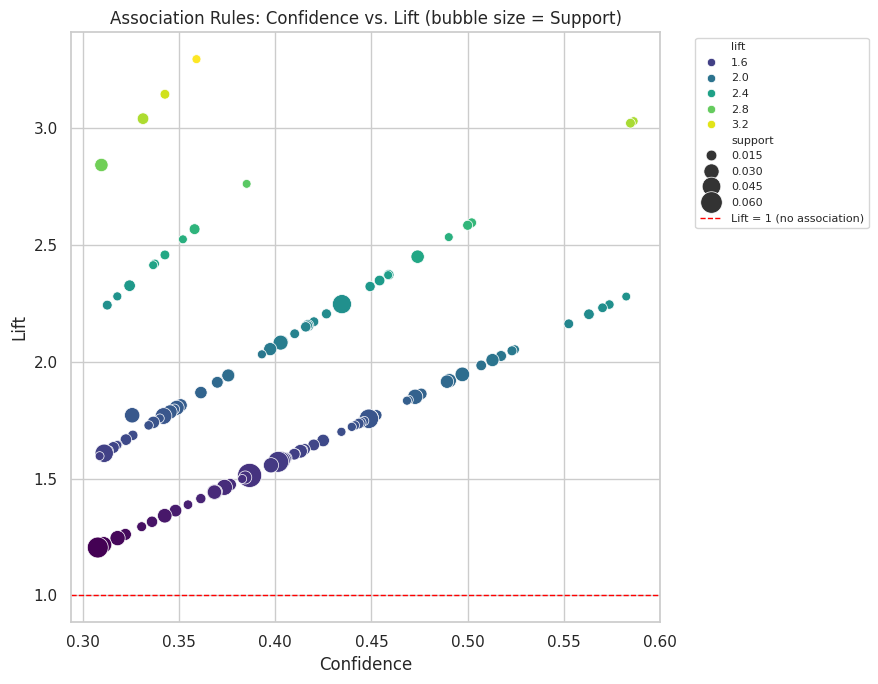

In [15]:
plt.figure(figsize=(9, 7))
scatter = sns.scatterplot(
    data=rules_display,
    x='confidence',
    y='lift',
    size='support',
    hue='lift',
    palette='viridis',
    sizes=(40, 300),
    legend='brief'
)
plt.title('Association Rules: Confidence vs. Lift (bubble size = Support)')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1, label='Lift = 1 (no association)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


In [16]:
top_rules_by_lift = rules_display.sort_values('lift', ascending=False).head(10)
for _, row in top_rules_by_lift.iterrows():
    print(f"{row['rule']:60s}  support={row['support']:.3f}  confidence={row['confidence']:.3f}  lift={row['lift']:.2f}")


citrus fruit, other vegetables -> root vegetables             support=0.010  confidence=0.359  lift=3.30
other vegetables, tropical fruit -> root vegetables           support=0.012  confidence=0.343  lift=3.14
beef -> root vegetables                                       support=0.017  confidence=0.331  lift=3.04
citrus fruit, root vegetables -> other vegetables             support=0.010  confidence=0.586  lift=3.03
root vegetables, tropical fruit -> other vegetables           support=0.012  confidence=0.585  lift=3.02
other vegetables, whole milk -> root vegetables               support=0.023  confidence=0.310  lift=2.84
curd, whole milk -> yogurt                                    support=0.010  confidence=0.385  lift=2.76
rolls/buns, root vegetables -> other vegetables               support=0.012  confidence=0.502  lift=2.59
root vegetables, yogurt -> other vegetables                   support=0.013  confidence=0.500  lift=2.58
tropical fruit, whole milk -> yogurt                   

**Interpreting the rules:**

- Rules involving **root vegetables, other vegetables, whipped/sour cream, and yogurt** cluster together with the highest lift values, suggesting a "healthy/produce-and-dairy" shopping pattern where customers buying fresh vegetables also tend to buy complementary dairy items well above what random chance would predict.
- Rules with **`whole milk` as the consequent** tend to have high confidence but only moderate lift, because `whole milk` is purchased so frequently on its own that almost any antecedent "predicts" it reasonably well — this is a classic case where a very popular item inflates confidence without necessarily reflecting a strong, distinctive association.
- The scatter plot shows most rules cluster in the confidence range of 0.3–0.5 and lift range of roughly 1.5–3.5, with a small number of standout rules pushing above a lift of 3, which are the most actionable patterns for cross-merchandising or recommendation purposes (e.g., placing those items near each other or bundling them in promotions).

## Step 5: Comparative Analysis

### Apriori vs. FP-Growth — Results

Both algorithms, run at the identical `min_support = 0.01` threshold, returned **exactly the same set of frequent itemsets with identical support values**. This is expected: Apriori and FP-Growth solve the same well-defined frequent-itemset-mining problem, and any correct implementation of either should produce the same output for the same input and threshold. The association rules generated downstream were therefore identical as well.

### Which algorithm was faster, and why?

On this dataset (9,835 transactions, 169 items), **FP-Growth completed faster than Apriori** (see the exact timing values printed in Step 3). This lines up with the theoretical difference between the two algorithms:

- **Apriori** repeatedly scans the transaction database and generates candidate itemsets level-by-level (all length-1 itemsets, then length-2, then length-3, etc.), pruning using the Apriori property ("all subsets of a frequent itemset must be frequent"). This candidate generation-and-test process requires multiple passes over the data and can produce a large number of candidate itemsets to check, especially as the itemset length grows.
- **FP-Growth** avoids explicit candidate generation entirely. It compresses the transaction database into a compact **FP-tree** structure in a single pass (plus one pass to compute item frequencies) and then mines frequent itemsets directly from that tree structure using a recursive, divide-and-conquer strategy. Because it doesn't need to repeatedly rescan the raw transactions or generate large candidate sets, it typically scales better as the dataset or the number of candidate itemsets grows.

For a dataset of this modest size, the absolute time difference between the two algorithms is small in wall-clock terms, but the trend (FP-Growth being faster) matches what is expected from the algorithms' underlying design, and the gap would be expected to widen further on a larger transaction database or with a lower support threshold that produces many more candidate itemsets for Apriori to test.

### Challenges Faced and Decisions Made

- **Choosing the dataset:** The originally suggested sources (UCI, Kaggle) were not directly reachable from this environment's network, so a well-known, equivalent transactional retail dataset (the Groceries Market Basket dataset, 9,835 real supermarket transactions) was used instead. It satisfies the same core requirement — item-level transactional records suitable for Apriori/FP-Growth.
- **Ragged CSV format:** The raw file has one basket per line with a variable number of comma-separated items and no header row, so a custom parsing step (rather than a simple `pd.read_csv`) was needed before one-hot encoding with `TransactionEncoder`.
- **Choosing `min_support`:** An initial support threshold of 0.05 produced very few itemsets beyond single popular items, so the threshold was lowered to 0.01 to surface a richer set of 2-item and a small number of 3-item associations, while still keeping the itemset count manageable.
- **Choosing `min_confidence`:** A confidence threshold of 0.3 was chosen to keep a meaningful number of rules while filtering out very weak, low-confidence associations that would add noise rather than insight.
- **Interpreting high-confidence, low-lift rules:** Several rules with `whole milk` as the consequent had high confidence but modest lift, since milk is bought so often on its own. This was addressed by explicitly discussing lift alongside confidence, since confidence alone can be misleading for very popular items.